# Comparing centers.csv and numpy grid methods
### To run these codes, activate the tf_env

In [33]:
# import pandas as pd
# import numpy as np
# import tensorflow as tf

# grid = pd.read_csv("/home/shilaj/repitframework/repitframework/Assets/natural_convection/centres.csv", header=None)
# t_data = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.01.npy")

# grid = grid.drop(0, axis=0).astype(np.float32)
# grid_tf = tf.reshape(grid, shape=[-1,4])
# grid_np = grid_tf.numpy()
# ngrid_xnp = np.array(200*grid_np[:,1:2]+0.51, dtype=np.int64)
# ngrid_ynp = np.array(200*grid_np[:,2:3]+0.51, dtype=np.int64)

In [34]:
# t_matrix = np.ones([200,200])
# for i in range(0, 40000):
#     ngrid_x = ngrid_xnp[i]
#     ngrid_y = ngrid_ynp[i]
#     t_matrix[ngrid_x-1,ngrid_y-1] = t_data[i]

In [35]:
# t_matrix_np = t_data.reshape(200,200, order='F')

## Below comparison shows that; to conform it with professor's code we have to order it in F-major order

In [36]:
# np.allclose(t_matrix, t_matrix_np)


True

# Comparing professor's method and my method for feature selection:

In [58]:
import numpy as np
from pathlib import Path
import json
import Ofpp
import re
from repitframework import OpenFOAM

In [59]:
data = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.01.npy")
ux = data[:, 0].reshape(200,200, order="F")
uy = data[:, 1].reshape(200,200, order="F")

In [ ]:
# Professors method: 
ux_pad = np.pad(ux, ((1,1), (1,1)), mode="constant", constant_values=0)
prof_method_ux = np.zeros([39204, 5])
k = 0
for i in range(2,200):
	for j in range(2,200):
		prof_method_ux[k,0] = ux_pad[i,j]
		prof_method_ux[k,1] = ux_pad[i-1,j]
		prof_method_ux[k,2] = ux_pad[i+1,j]
		prof_method_ux[k,3] = ux_pad[i,j-1]
		prof_method_ux[k,4] = ux_pad[i,j+1]
		k += 1

In [ ]:
# My method:
window_shape = (3, 3)
sliding_window = np.lib.stride_tricks.sliding_window_view(ux, window_shape)
x,y = 1,1
correlated_features = np.stack([
	sliding_window[:,:,x,y],
	sliding_window[:,:,x-1,y],
	sliding_window[:,:,x+1,y],
	sliding_window[:,:,x,y-1],
	sliding_window[:,:,x,y+1]
],axis=-1).reshape(-1,5)

In [65]:
ux

array([[-0.0119128 , -0.00999168, -0.00788239, ...,  0.0246806 ,
         0.0189697 , -0.00594518],
       [-0.0169824 , -0.0160015 , -0.0133442 , ...,  0.066698  ,
         0.0629324 ,  0.0460888 ],
       [-0.0148263 , -0.0170253 , -0.0158739 , ...,  0.112206  ,
         0.112176  ,  0.0991994 ],
       ...,
       [-0.0110955 , -0.0269181 , -0.0382983 , ...,  0.012997  ,
         0.0128753 ,  0.00976527],
       [ 0.0135006 , -0.00434889, -0.0176506 , ...,  0.00971267,
         0.0108962 ,  0.0101799 ],
       [ 0.0108766 ,  0.0096557 ,  0.00640758, ...,  0.00424294,
         0.00531634,  0.00598413]])

In [63]:
prof_method_ux

array([[-0.0160015 , -0.00999168, -0.0170253 , -0.0169824 , -0.0133442 ],
       [-0.0133442 , -0.00788239, -0.0158739 , -0.0160015 , -0.0115032 ],
       [-0.0115032 , -0.00639967, -0.0144757 , -0.0133442 , -0.0101853 ],
       ...,
       [ 0.00876966,  0.0125816 ,  0.00346555,  0.00805921,  0.00971267],
       [ 0.00971267,  0.012997  ,  0.00424294,  0.00876966,  0.0108962 ],
       [ 0.0108962 ,  0.0128753 ,  0.00531634,  0.00971267,  0.0101799 ]])

In [64]:
correlated_features

array([[-0.0160015 , -0.00999168, -0.0170253 , -0.0169824 , -0.0133442 ],
       [-0.0133442 , -0.00788239, -0.0158739 , -0.0160015 , -0.0115032 ],
       [-0.0115032 , -0.00639967, -0.0144757 , -0.0133442 , -0.0101853 ],
       ...,
       [ 0.00876966,  0.0125816 ,  0.00346555,  0.00805921,  0.00971267],
       [ 0.00971267,  0.012997  ,  0.00424294,  0.00876966,  0.0108962 ],
       [ 0.0108962 ,  0.0128753 ,  0.00531634,  0.00971267,  0.0101799 ]])

In [62]:
np.allclose(prof_method_ux, correlated_features)

True

# Comparing normalization and denormalization using numpy and pandas

In [29]:
import numpy as np
import pandas as pd

In [28]:
ml_dataset = np.random.rand(39204*2, 18)
dataset = ml_dataset[:,3:18]
train_labels = ml_dataset[:,0:3]

In [38]:
# Normalize the dataset using pandas:
dataset_df = pd.DataFrame(dataset)
train_stats = dataset_df.describe().transpose()

labels_df = pd.DataFrame(train_labels)
labels_stats = labels_df.describe().transpose()

In [40]:
normed_dataset = (dataset_df - train_stats['mean']) / train_stats['std']
normed_labels = (labels_df - labels_stats['mean']) / labels_stats['std']
unnormed_labels = (normed_labels * labels_stats['std']) + labels_stats['mean']

In [41]:
# Normalize the dataset using numpy:
mean_train = np.mean(dataset, axis=0)
std_train  = np.std(dataset, axis=0)

mean_labels = np.mean(train_labels, axis=0)
std_labels = np.std(train_labels, axis=0)

normed_dataset_np = (dataset - mean_train) / std_train
normed_labels_np = (train_labels - mean_labels) / std_labels
unnormed_labels_np = (normed_labels_np * std_labels) + mean_labels

In [47]:
np.allclose(normed_dataset, normed_dataset_np)

True

In [48]:
np.allclose(normed_labels, normed_labels_np)

True

In [51]:
np.allclose(unnormed_labels, unnormed_labels_np)

True

In [53]:
np.allclose(unnormed_labels, train_labels)

True

# Comparing difference calculation using framework and numpy

In [1]:
import numpy as np

from repitframework.OpenFOAM.utils import OpenfoamUtils
from repitframework.config import TrainingConfig
from repitframework.Dataset.fvmn import FVMNDataset

In [2]:
training_config = TrainingConfig()
fvmn_dataset = FVMNDataset(training_config)
t_1002 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.02.npy")
t_1003 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.03.npy")
u_1002 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.02.npy")
u_1003 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.03.npy")

In [3]:
input_data = fvmn_dataset._prepare_input(10.02)

In [13]:
t_framework_internal = input_data[:,::5][:,2:]

In [14]:
t_1002_internal = t_1002.reshape(200,200, order='F')[1:-1,1:-1].reshape(-1,1, order='F')

In [15]:
np.allclose(t_framework_internal, t_1002_internal)

True

In [16]:
# Load T value for time step 10.02 and 10.03:
t_now = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.01.npy").reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
t_next = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.02.npy").reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
u_now = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.01.npy")
ux_now = u_now[:,0].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
uy_now = u_now[:,1].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
U_next = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.02.npy")
ux_next = U_next[:,0].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
uy_next = U_next[:,1].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")

data_now = np.concatenate([ux_now,uy_now, t_now], axis=1)
data_next = np.concatenate([ux_next, uy_next, t_next], axis=1)
data_diff_np = data_next - data_now

In [17]:
data_diff_framework = fvmn_dataset._calculate_difference(time=10.01)

In [20]:
np.allclose(data_diff_np, data_diff_framework)

True

# Run the prediction (Using professor's way trained network)

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

def make_mlp(input_dim=15, hidden_dim=512, num_hidden_layers=11, output_dim=1):
	# In Keras code: 
	# - input_shape=(15,) 
	# - 11 layers of Dense(512, relu)
	# - 1 layer of Dense(1)
	layers = []
	layers.append(nn.Linear(input_dim, hidden_dim))
	layers.append(nn.ReLU())
	for _ in range(num_hidden_layers - 1):
		layers.append(nn.Linear(hidden_dim, hidden_dim))
		layers.append(nn.ReLU())
	layers.append(nn.Linear(hidden_dim, output_dim))
	return nn.Sequential(*layers)

# Define the networks from the snippet
class NetA(nn.Module):
	def __init__(self):
		super(NetA, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetP(nn.Module):
	def __init__(self):
		super(NetP, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetPH(nn.Module):
	def __init__(self):
		super(NetPH, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetU(nn.Module):
	def __init__(self):
		super(NetU, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetV(nn.Module):
	def __init__(self):
		super(NetV, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

# The PyTorch equivalent of FVMN model that holds multiple subnetworks
class FVMN(nn.Module):
	def __init__(self, use_p=False, use_ph=False):
		super(FVMN, self).__init__()
		self.net_a = NetA()
		self.net_u = NetU()
		self.net_v = NetV()
		# If you want to use net_p or net_ph:
		self.use_p = use_p
		self.use_ph = use_ph
		if self.use_p:
			self.net_p = NetP()
		if self.use_ph:
			self.net_ph = NetPH()

	def forward(self, x):
		# x should be shape [batch, 15] for these subnets
		pred_a = self.net_a(x)
		pred_u = self.net_u(x)
		pred_v = self.net_v(x)
		
		# If needed:
		if self.use_p:
			pred_p = self.net_p(x)
		else:
			pred_p = None
		
		if self.use_ph:
			pred_ph = self.net_ph(x)
		else:
			pred_ph = None

		# Return predictions as a dict or tuple
		# Keras code references these predictions separately. 
		# Let's return as a dictionary for clarity:
		return {
			'a': pred_a, 
			'u': pred_u, 
			'v': pred_v
		}


In [27]:
from repitframework.Models.FVMN.fvmn import FVMNetwork
from repitframework.config import TrainingConfig, OpenfoamConfig
from repitframework.Dataset.fvmn import FVMNDataset
from runner import Trainer, get_dataloader

In [31]:
training_config = TrainingConfig()
model = FVMNetwork(training_config)
# trainer = Trainer(training_config,model, training_config.optimizer,
# 				  training_config.loss, model_name="pt_checkpoint.pth")

In [ ]:
import json
predicted_output = np.load("/home/shilaj/repitframework/denormed_data_1003.npy")
combined_output = np.load("/home/shilaj/repitframework/data_1003.npy")
prev_output = combined_output - predicted_output

with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/denorm_metrics.json", "r") as f:
	metrics = json.load(f)
	
predicted_output = (predicted_output * metrics["label_STD"]) + metrics["label_MEAN"]
predicted_output = predicted_output + prev_output
predicted_output_t = np.flipud(predicted_output[:,0].reshape(198,198, order="F"))
predicted_output_ux = np.flipud(predicted_output[:,1].reshape(198,198, order="F"))
predicted_output_uy = np.flipud(predicted_output[:,2].reshape(198,198, order="F"))

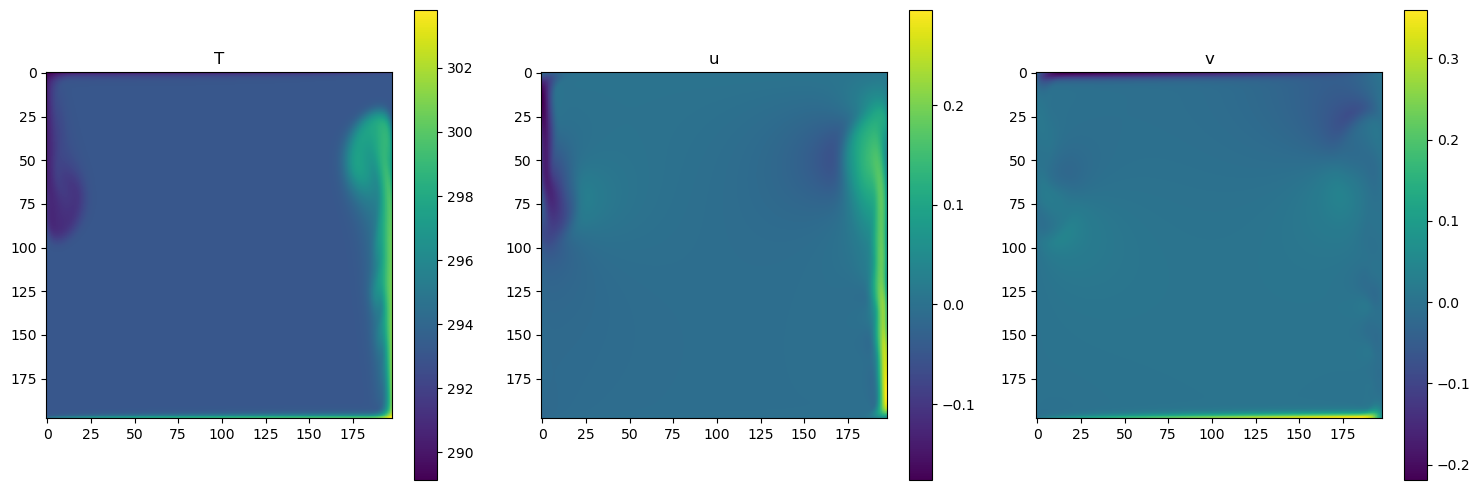

In [13]:
# Visualize the results
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(predicted_output_t)
ax[0].set_title('T')
fig.colorbar(ax[0].imshow(predicted_output_t))
ax[1].imshow(predicted_output_ux)
ax[1].set_title('u')
fig.colorbar(ax[1].imshow(predicted_output_ux))
ax[2].imshow(predicted_output_uy)
ax[2].set_title('v')
fig.colorbar(ax[2].imshow(predicted_output_uy))
plt.tight_layout()

# Comparing professor's data sample and mine

In [1]:
import pandas as pd
import numpy as np

prof_data_1001 = pd.read_csv("/home/shilaj/shilaj_data/repit_code/DataSample/traindata10.01.csv")
prof_t = prof_data_1001["T"].values
prof_ux = prof_data_1001["Ux"].values
prof_uy = prof_data_1001["Uy"].values

my_t = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.01.npy")
my_u = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.01.npy")
my_ux = my_u[:,0]
my_uy = my_u[:,1]



# Load professor's ways trained model

In [19]:
import torch

model_dict = torch.load("/home/shilaj/shilaj_data/repit_code/pt_checkpoint.pth", weights_only=True)
model = model_dict["model_state_dict"]

model_test = torch.load("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/best_model.pth", weights_only=True)

In [32]:
model.load_state_dict(model_test)

<All keys matched successfully>

In [33]:
model.parameters()

<generator object Module.parameters at 0x74deb5f31d20>

In [41]:
a = np.random.rand(1000,3)
a[:,0:1].shape

(1000, 1)

In [ ]:
from repitframework.plot_utils import visualize_output
from repitframework.config import BaseConfig

base_config = BaseConfig()
visualize_output(base_config=base_config, 
				 timestamp=12.4,
				 is_ground_truth=False,
				 save_name="predicted")

/home/shilaj/repitframework/repitframework/plot_utils.py:57: UserWarning: 

Data dimension mismatch: 
	Variable shape: (40000, 1)
	Expected data dimension: 2
Please update the data_dim parameter in the config file if you want to visualize all the dimensions of the data.

  warnings.warn(warning_string.format(shape_of_variable, data_dim))


True

In [3]:
from datetime import datetime

start_time = datetime.strptime("15:22:12", "%H:%M:%S")
end_time = datetime.strptime("16:34:20", "%H:%M:%S")


# Visualizing things

# Visualizing outputs

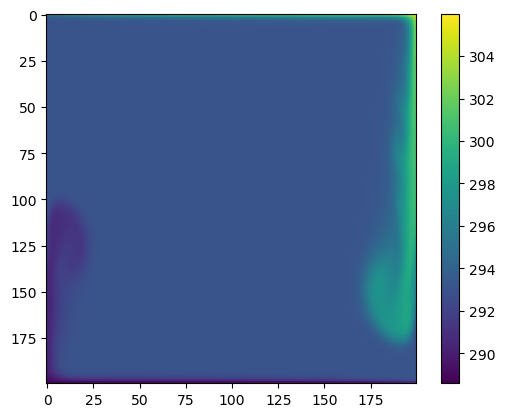

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

my_t = np.load("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection/T_10.1.npy")
my_t = my_t.reshape(200,200, order="F")

plt.imshow(my_t)
plt.colorbar()

In [83]:
a = np.random.rand(100, 15)
a[:, ::5]

array([[7.34022101e-01, 8.44237706e-02, 7.61359935e-02],
       [7.61632706e-01, 4.45631494e-01, 1.51761946e-01],
       [2.94432095e-01, 4.46502733e-03, 4.58997292e-01],
       [2.15930830e-02, 8.90331404e-01, 5.15439586e-01],
       [1.13290925e-01, 7.93133131e-01, 1.05006822e-01],
       [9.60197194e-01, 1.72144064e-01, 2.64578039e-01],
       [5.37358914e-01, 3.98268344e-01, 7.48202577e-01],
       [8.93366940e-01, 7.87414574e-01, 2.60271398e-01],
       [2.17998408e-01, 2.12967173e-01, 6.76129080e-01],
       [9.83370251e-01, 3.83301723e-01, 9.31458534e-01],
       [9.70504388e-01, 6.73337452e-01, 4.61314844e-01],
       [6.90561870e-01, 8.00266638e-01, 2.49392265e-01],
       [7.35198757e-01, 7.79045847e-01, 6.49633453e-01],
       [8.68415842e-01, 2.15848431e-01, 2.06632700e-01],
       [5.54608666e-01, 1.35719928e-01, 8.32448178e-01],
       [1.85081266e-01, 7.29519118e-01, 8.26998947e-01],
       [8.57724921e-01, 9.95209134e-01, 5.41678378e-01],
       [4.42344283e-01, 8.97047

In [91]:
a[:, 5].shape

(100,)

In [46]:
time_list_1 = np.arange(10.49,10.52,0.01)
time_list_2 = np.arange(10.01,10.05,0.01)

In [61]:
num_points = np.ceil((10.02 - 10.0)/0.01) + 1
time_list = np.round(np.linspace(10.0, 10.02, int(num_points)),2)

In [63]:
time_list

array([10.  , 10.01, 10.02])

# Visualizing Relative Residual Mass

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/prediction_metrics.json", "r") as f:
	metrics = json.load(f)

# x_ticks = [10.03]
# for i in range(len(first_running_time)):
#     if first_relative_residual[i] >= 5.0:
#         x_ticks.append(first_running_time[i+1])

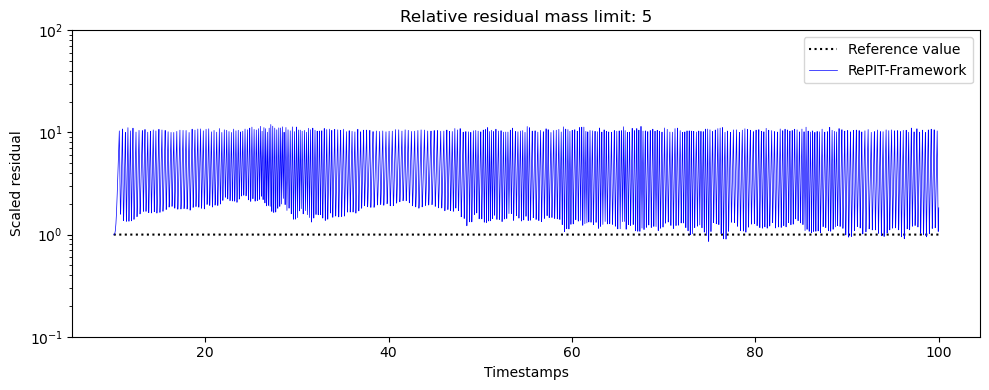

In [6]:
running_times = metrics["Running Time"]

relative_residual = metrics["Relative Residual Mass"]
true_residual = np.ones_like(relative_residual)

plt.figure(figsize=(10,4))
plt.plot(running_times, true_residual, ":k", label="Reference value")
plt.plot(running_times, relative_residual, "-b", label="RePIT-Framework", linewidth=0.5)
plt.ylim(0.1,100)
# plt.xlim(10, 20)
# plt.xticks(x_ticks)
plt.xlabel("Timestamps")
plt.yscale("log", base=10)
plt.ylabel("Scaled residual")
plt.legend()
plt.title("Relative residual mass limit: 5")
plt.tight_layout()
plt.savefig("/home/shilaj/repitframework/repitframework/plots/natural_convection/relative_residual_2epochs.png")

648

In [63]:
np.random.seed(42)
t_51_predicted = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.51_predicted.npy").reshape(200,200, order="F")
u_1001 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.51_predicted.npy")
ux_51_predicted = u_1001[:,0].reshape(200,200, order="F")
uy_51_predicted = u_1001[:,1].reshape(200,200, order="F")

t_51 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.51.npy").reshape(200,200, order="F")
u_1002 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.51.npy")
ux_51 = u_1002[:,0].reshape(200,200, order="F")
uy_51 = u_1002[:,1].reshape(200,200, order="F")

ground_truth = [t_51, ux_51, uy_51]
difference = [t_51_predicted - t_51, ux_51_predicted - ux_51, uy_51_predicted - uy_51]

# Checking Residual Values for Predicted-CFD and Ground-Truth CFD

In [13]:
import Ofpp
import numpy as np
import matplotlib.pyplot as plt
from repitframework.Metrics.ResidualNaturalConvection import residual_mass
import imageio

In [14]:
residual_ground_truth = []
residual_predicted = []

In [ ]:
def plot_difference(timestamp):
	framework_t = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_{timestamp}.npy").reshape(200,200, order="F")
	ground_truth_t = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_backup/T_{timestamp}.npy").reshape(200,200, order="F")

	framework_u = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_{timestamp}.npy")
	ground_truth_u = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_backup/U_{timestamp}.npy")
	framework_ux = framework_u[:,0].reshape(200,200, order="F")
	framework_uy = framework_u[:,1].reshape(200,200, order="F")
	ground_truth_ux = ground_truth_u[:,0].reshape(200,200, order="F")
	ground_truth_uy = ground_truth_u[:,1].reshape(200,200, order="F")

	residual_ground_truth.append(residual_mass(ground_truth_ux, ground_truth_uy))
	residual_predicted.append(residual_mass(framework_ux, framework_uy))

	fig, ax = plt.subplots(2,2, figsize=(10,15))
	fig.suptitle(f"Comparison between Ground truth and Framework results: {timestamp}")

	ax[0,0].imshow(framework_uy)
	ax[0,0].set_title("Framework Ground Truth Uy")
	plt.colorbar(ax[0,0].imshow(framework_uy))
	ax[0,1].imshow(framework_ux)
	ax[0,1].set_title("Framework Ground Truth Ux")
	plt.colorbar(ax[0,1].imshow(framework_ux))
	ax[0,2].imshow(framework_t)
	ax[0,2].set_title("Framework Ground Truth T")
	plt.colorbar(ax[0,2].imshow(framework_t))

	ax[1,0].imshow(ground_truth_uy)
	ax[1,0].set_title("Ground Truth Uy")
	plt.colorbar(ax[1,0].imshow(ground_truth_uy))
	ax[1,1].imshow(ground_truth_ux)
	ax[1,1].set_title("Ground Truth Ux")
	plt.colorbar(ax[1,1].imshow(ground_truth_ux))
	ax[1,2].imshow(ground_truth_t)
	ax[1,2].set_title("Ground Truth T")
	plt.colorbar(ax[1,2].imshow(ground_truth_t))

	# ax[2,0].imshow(framework_uy - ground_truth_uy)
	# ax[2,0].set_title("Difference Uy")
	# plt.colorbar(ax[2,0].imshow(framework_uy - ground_truth_uy))
	# ax[2,1].imshow(framework_ux - ground_truth_ux)
	# ax[2,1].set_title("Difference Ux")
	# plt.colorbar(ax[2,1].imshow(framework_ux - ground_truth_ux))
	# ax[2,2].imshow(framework_t - ground_truth_t)
	# ax[2,2].set_title("Difference T")
	# plt.colorbar(ax[2,2].imshow(framework_t - ground_truth_t))
	# plt.tight_layout()

	fig.canvas.draw()
	rgb_array = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(fig.canvas.get_width_height()[::-1] + (4,))
	plt.close()
	return rgb_array


def generate_time(start_time, end_time, step):
	timestamps = []
	while start_time <= end_time:
		start_time = round(start_time, 2)
		timestamps.append(start_time)
		start_time += step
	return timestamps


In [ ]:
images_list = []
time_list = generate_time(10.51, 20.0, 0.01)
for time in time_list:
	images_list.append(plot_difference(time))

imageio.mimsave("/home/shilaj/repitframework/repitframework/difference_animation_step_3.gif", images_list, fps=50)

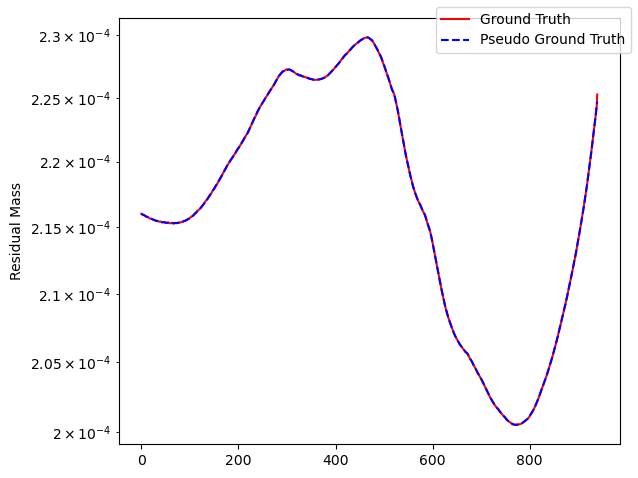

In [8]:
fig, ax = plt.subplots()

ax.plot(residual_ground_truth[10:], label="Ground Truth", color="red", linestyle="-")
ax.plot(residual_predicted[10:], label="Pseudo Ground Truth", color="blue", linestyle="--")
ax.set_ylabel("Residual Mass")
fig.legend()
ax.set_yscale("log")
fig.tight_layout()
fig.savefig("/home/shilaj/repitframework/repitframework/residual_mass_comparison_step_3_After10thTimeStep.png")

In [6]:
import numpy as np
import matplotlib.pyplot as plt

t_1001 = np.load("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection/T_10.03.npy")
u_1001 = np.load("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection/U_10.02.npy")
t_1001 = t_1001.reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
u_1001 = u_1001.reshape(200,200,3, order="F")[1:-1,1:-1,:].reshape(-1,3, order="F")


In [7]:
t_avg = np.mean(t_1001)

# Dissecting Ofpp library

In [ ]:
file_path = "/home/shilaj/shilaj_data/repitframework/repitframework/Solvers/natural_convection/10.01/phi"

with open(file_path, "r") as f:
	content = f.readlines()
	
content

['/*--------------------------------*- C++ -*----------------------------------*\\\n',
 '  =========                 |\n',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox\n',
 '   \\\\    /   O peration     | Website:  https://openfoam.org\n',
 '    \\\\  /    A nd           | Version:  12\n',
 '     \\\\/     M anipulation  |\n',
 '\\*---------------------------------------------------------------------------*/\n',
 'FoamFile\n',
 '{\n',
 '    format      ascii;\n',
 '    class       surfaceScalarField;\n',
 '    location    "10.01";\n',
 '    object      phi;\n',
 '}\n',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //\n',
 '\n',
 'dimensions      [1 0 -1 0 0 0 0];\n',
 '\n',
 'internalField   nonuniform List<scalar> \n',
 '79600\n',
 '(\n',
 '-9.07055498999e-06\n',
 '9.07025804464e-06\n',
 '-9.60743292583e-06\n',
 '5.36614627241e-07\n',
 '-7.90299560801e-06\n',
 '-1.70469491245e-06\n',
 '-6.20630407788e-06\n',
 '-1.69694135925

In [ ]:
from repitframework.OpenFOAM.utils import OpenfoamUtils
import numpy as np

spatial_range = OpenfoamUtils.generate_intervals(
	0.005, 200*0.005, 0.005, 3
)
spatial_range = np.array(spatial_range).reshape(-1,)



In [ ]:
from repitframework.Models.FVMN.fvmn import FVMNetwork
from repitframework.config import TrainingConfig
from repitframework.Dataset.fvmn import FVMNDataset
from typing import Tuple
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torch


def get_dataloader(training_config:TrainingConfig, 
				   dataset:FVMNDataset, 
				   batch_size=None)->Tuple[DataLoader, DataLoader]:
	'''
	Get the dataloaders for training and validation.
	'''
	batch_size = batch_size if batch_size else training_config.batch_size

	# Indices for splitting
	data_size = len(dataset)
	indices = list(range(data_size))
	train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=1004)

	# Subsets
	train_dataset = Subset(dataset, train_indices)
	val_dataset = Subset(dataset, val_indices)

	# Dataloaders
	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,drop_last=True)
	val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

	return train_loader, val_loader

training_config = TrainingConfig()
model = FVMNetwork(training_config)
dataset = FVMNDataset(training_config,
					  first_training=False,
					  start_time=10.0,
					  end_time=10.02)
train_loader,val_loader = get_dataloader(training_config, dataset)
model_path = "/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/best_model_gt.pth"
model.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [ ]:

with torch.no_grad():
	val_loss = 0.0
	for x_val, y_val in train_loader:
		x_val = x_val
		y_val = y_val

		# Labels: 
		y_T = y_val[:,0:1]
		y_ux = y_val[:, 1:2]
		y_uy = y_val[:, 2:3]

		# Forward pass: Hard coded
		predictions = model(x_val)
		pred_T = predictions["T"]
		pred_ux = predictions["U_x"]
		pred_uy = predictions["U_y"]

		loss_T = torch.nn.MSELoss()(pred_T, y_T)
		loss_ux = torch.nn.MSELoss()(pred_ux, y_ux)
		loss_uy = torch.nn.MSELoss()(pred_uy, y_uy)
		loss = loss_T + loss_ux + loss_uy

		val_loss += loss.item() * x_val.size(0)

val_loss /= len(train_loader.dataset)


In [167]:
val_loss

0.4369572790342892

In [29]:
import numpy as np
T_1001 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.02.npy")
T_backup = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_backup/U_10.02.npy")
prof_t = np.load("/home/shilaj/repitframework/repitframework/Assets/U_10.02.npy")

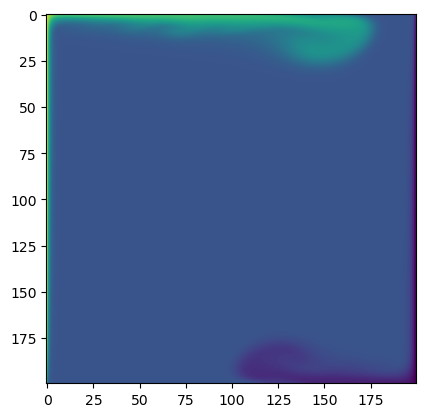

In [31]:
import matplotlib.pyplot as plt

plt.imshow(np.flipud(T_1001.reshape(200,200)))

# Train Phi Network

In [133]:
import torch.optim as optim
import torch
import numpy as np
from torch.utils.data import DataLoader
from repitframework.Models.FVMN.fvmn import ConvPhiNet
from repitframework.config import TrainingConfig
from repitframework.Dataset.fvmn import PhiDataset
import tqdm
import json


training_config = TrainingConfig()
# Model instance
torch.cuda.empty_cache()
phi_model = ConvPhiNet()


In [ ]:
u_1053 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.53.npy")
ux = u_1053[:,0].reshape(200,200, order="F")
uy = u_1053[:,1].reshape(200,200, order="F")
u = np.stack([ux, uy], axis=0)
u_ = np.reshape(u, (1,2,200,200))


with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/phi_denorm_metrics.json", "r") as f:
	metrics = json.load(f)
phi_input_mean = np.array(metrics["phi_input_MEAN"])
phi_input_std = np.array(metrics["phi_input_STD"])
phi_label_mean = np.array(metrics["phi_label_MEAN"])
phi_label_std = np.array(metrics["phi_label_STD"])

u_ = (u_ - phi_input_mean) / phi_input_std
input = torch.Tensor(u_).to("cuda")

In [135]:
phi_model.to("cuda")
phi_model.load_state_dict(torch.load("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/phi_model.pth", weights_only=True, map_location="cuda:1"))

<All keys matched successfully>

In [137]:
output = phi_model(input)

In [157]:
output.shape

(1, 79600)

In [138]:
output = output.cpu().detach().numpy()
output = (output * phi_label_std) + phi_label_mean

In [46]:
from Ofpp import parse_internal_field
import matplotlib.pyplot as plt
import torch
import numpy as np

time = 10.53
with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/phi_denorm_metrics_1.json", "r") as f:
	metrics = json.load(f)
input_mean = metrics["phi_input_MEAN"]
input_std = metrics["phi_input_STD"]
label_mean = metrics["phi_label_MEAN"]
label_std = metrics["phi_label_STD"]
true_phi = parse_internal_field(f"/home/shilaj/repitframework/repitframework/Assets/CFD_full_simulation/{time}/phi")
vel_input = parse_internal_field(f"/home/shilaj/repitframework/repitframework/Assets/CFD_full_simulation/{time}/U")[:,:2]
normed_input = (vel_input - input_mean) / input_std

model = torch.nn.Linear(2,2).to("cuda")
model.load_state_dict(torch.load("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/phi_model_linear.pth", weights_only=True))


<All keys matched successfully>

In [52]:
input = torch.Tensor(normed_input).to("cuda")
output = model(input)
output = output.cpu().detach().numpy()
predicted_phi = (output * label_std) + label_mean	
predicted_phi = predicted_phi.reshape(-1,order="C")[200:-200]

In [54]:
random_select = np.random.randint(0, 79600, size=100)

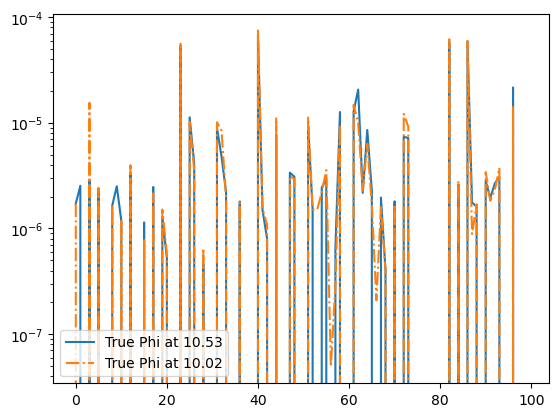

In [ ]:
x = np.arange(0,100,1)
plt.plot(x, true_phi[random_select], label="True Phi at 10.53")
# plt.plot(x, true_phi_1002[random_select], label="True Phi at 10.02", linestyle="-.")
plt.legend()
plt.yscale("log")
plt.show()

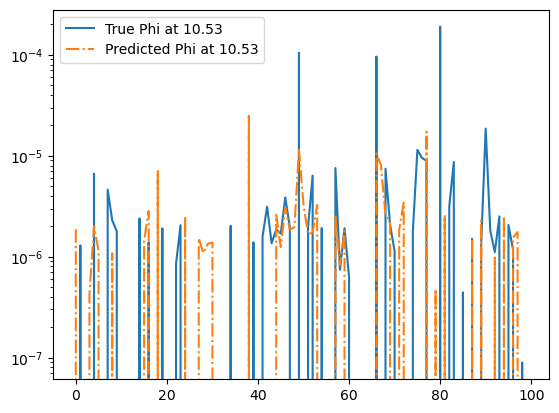

In [55]:
x = np.arange(0,100,1)
plt.plot(x, true_phi[random_select], label="True Phi at 10.53")
plt.plot(x, predicted_phi[random_select], label="Predicted Phi at 10.53", linestyle="-.")
plt.legend()
plt.yscale("log")
plt.show()

In [74]:
import numpy as np
import matplotlib.pyplot as plt

t_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_12.0_predicted.npy").reshape(200,200)
u_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_12.0_predicted.npy")[:,0].reshape(200,200)
t_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_20.0_predicted.npy").reshape(200,200)
u_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_20.0_predicted.npy")[:,0].reshape(200,200)


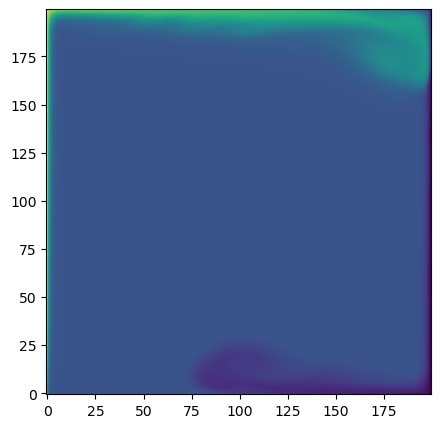

In [75]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
im1 = axs.imshow(t_12, origin="lower")

# Create the comparison table

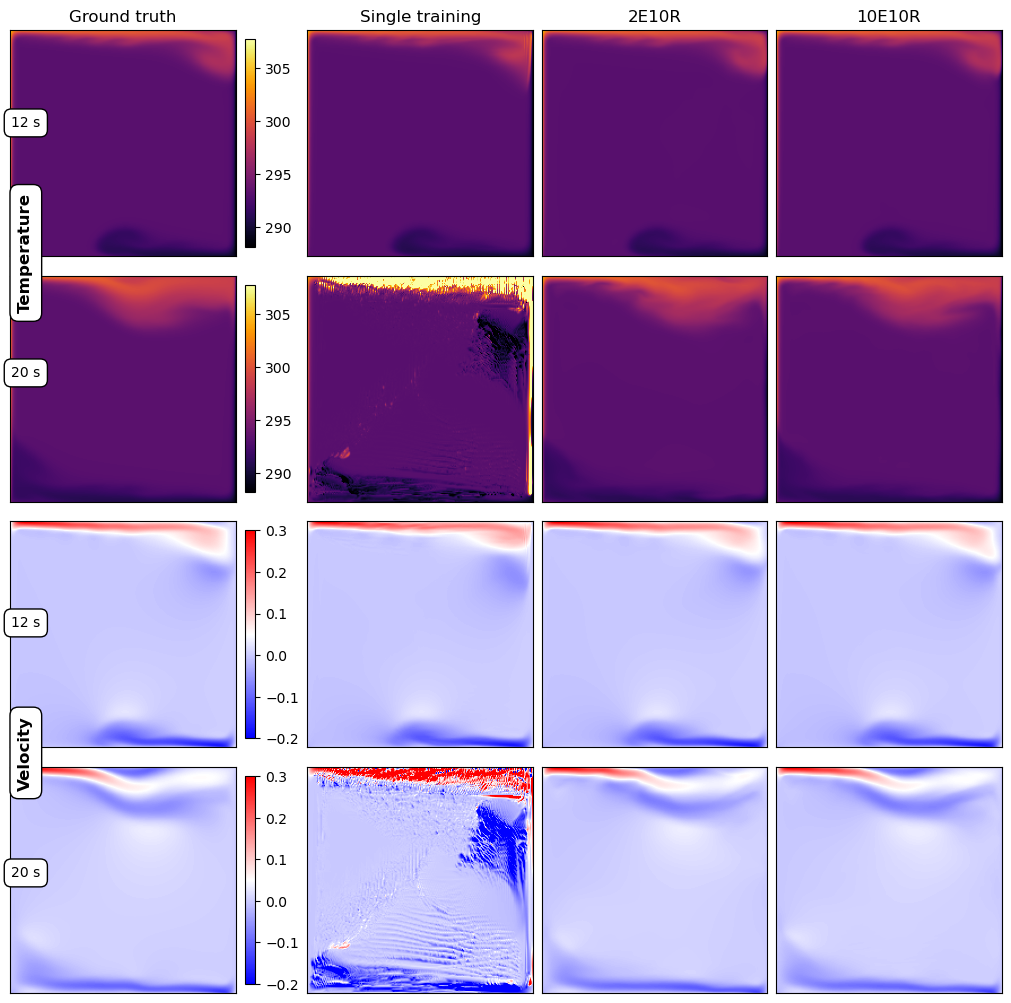

In [12]:
# Recreate the structured visualization with proper borders and labels
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Example data (replace with actual CFD data)
nx, ny = 200, 200  # Grid size
ground_truth_temp_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/T_12.0.npy").reshape(200,200)
ground_truth_temp_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/T_20.0.npy").reshape(200,200)
ground_truth_vel_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/U_12.0.npy")[:,0].reshape(200,200)
ground_truth_vel_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/U_20.0.npy")[:,0].reshape(200,200)

epoch2res10_temp_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch10Res/natural_convection_case1/T_12.0.npy").reshape(200,200)
epoch2res10_vel_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch10Res/natural_convection_case1/U_12.0.npy")[:,0].reshape(200,200)
epoch2res10_temp_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch10Res/natural_convection_case1/T_20.0.npy").reshape(200,200)
epoch2res10_vel_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch10Res/natural_convection_case1/U_20.0.npy")[:,0].reshape(200,200)

epoch2res5_temp_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch5Res/natural_convection_case1/T_12.0.npy").reshape(200,200)
epoch2res5_vel_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch5Res/natural_convection_case1/U_12.0.npy")[:,0].reshape(200,200)
epoch2res5_temp_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch5Res/natural_convection_case1/T_20.0_predicted.npy").reshape(200,200)
epoch2res5_vel_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch5Res/natural_convection_case1/U_20.0_predicted.npy")[:,0].reshape(200,200)

epoch2res100_temp_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch100Res/natural_convection_case1/T_12.0.npy").reshape(200,200)
epoch2res100_vel_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch100Res/natural_convection_case1/U_12.0.npy")[:,0].reshape(200,200)
epoch2res100_temp_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch100Res/natural_convection_case1/T_20.0_predicted.npy").reshape(200,200)
epoch2res100_vel_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/2epoch100Res/natural_convection_case1/U_20.0_predicted.npy")[:,0].reshape(200,200)

epoch10res10_temp_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/10epoch10Res/natural_convection_case1/T_12.0_predicted.npy").reshape(200,200)
epoch10res10_vel_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/10epoch10Res/natural_convection_case1/U_12.0_predicted.npy")[:,0].reshape(200,200)
epoch10res10_temp_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/10epoch10Res/natural_convection_case1/T_20.0_predicted.npy").reshape(200,200)
epoch10res10_vel_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/cases/10epoch10Res/natural_convection_case1/U_20.0_predicted.npy")[:,0].reshape(200,200)

single_training_temp_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/T_12.0_predicted.npy").reshape(200,200)
single_training_vel_12 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/U_12.0_predicted.npy")[:,0].reshape(200,200)
single_training_temp_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/T_20.0_predicted.npy").reshape(200,200)
single_training_vel_20 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/U_20.0_predicted.npy")[:,0].reshape(200,200)

# Arrange data in dictionary format for easy looping
data_dict = {
	"Ground truth": [ground_truth_temp_12, ground_truth_temp_20, ground_truth_vel_12, ground_truth_vel_20],
	"Single training": [single_training_temp_12, single_training_temp_20, single_training_vel_12, single_training_vel_20],
	# "2E5R": [epoch2res5_temp_12, epoch2res5_temp_20, epoch2res5_vel_12, epoch2res5_vel_20],
	"2E10R": [epoch2res10_temp_12, epoch2res10_temp_20, epoch2res10_vel_12, epoch2res10_vel_20],
	# "2E100R": [epoch2res100_temp_12, epoch2res100_temp_20, epoch2res100_vel_12, epoch2res100_vel_20]
	"10E10R": [epoch10res10_temp_12, epoch10res10_temp_20, epoch10res10_vel_12, epoch10res10_vel_20],
}

time_labels = ["12 s", "20 s"]
var_labels = ["Temperature", "Velocity"]

fig, axs = plt.subplots(4, 4 ,figsize=(10, 10), constrained_layout=True)

vmin_temp = 288.15
vmax_temp = 307.75

vmin_vel = -0.2
vmax_vel = 0.3
X = np.linspace(0, 199, 200, dtype=int)
Y = np.linspace(0, 199, 200, dtype=int)
X, Y = np.meshgrid(X, Y)
# Loop through rows and columns to fill in data
for row in range(4):  # 2 variables x 2 time steps
	for col, (title, data_list) in enumerate(data_dict.items()):
		vmin = np.min(data_list[row])
		vmax = np.max(data_list[row])
		if row in [0, 1]: img = axs[row, col].imshow(data_list[row], vmin=vmin_temp, vmax=vmax_temp, cmap="inferno", origin="lower") 
		else: img = axs[row, col].imshow(data_list[row], cmap="bwr", vmin=vmin_vel, vmax=vmax_vel,origin="lower")
		if title == "Ground truth": 
			cbar = plt.colorbar(img, ax=axs[row, col], fraction=0.046, pad=0.04)
		axs[row, col].set_xticks([])
		axs[row, col].set_yticks([])
		if row == 0:
			axs[row, col].set_title(title, fontsize=12)

# Add row labels for Temperature/Velocity
for row_idx, var_label in enumerate(var_labels):
	fig.text(0.02, 0.75 - row_idx * 0.5, var_label, va='center', ha='center', 
			 fontsize=12, fontweight='bold', rotation=90, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Add row labels for Time (12s, 20s) in both Temperature & Velocity sections
for row_idx, time_label in enumerate(time_labels):
	fig.text(0.02, 0.88 - row_idx * 0.25, time_label, va='center', ha='center', 
			 fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
	fig.text(0.02, 0.38 - row_idx * 0.25, time_label, va='center', ha='center', 
			 fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

plt.show()

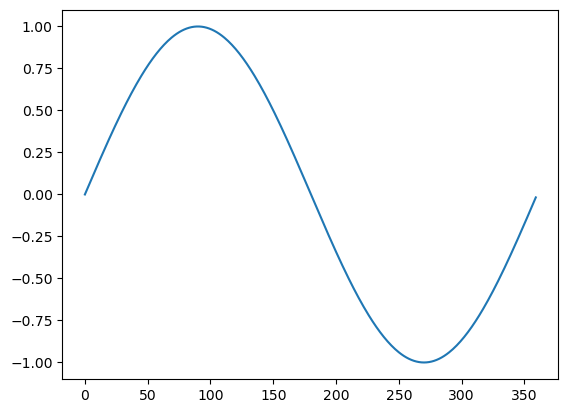

In [11]:
import numpy as np
import matplotlib.pyplot as plt


x = np.arange(0, 360, 1)
y = np.sin(np.radians(x))
plt.plot(x, y)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

timestep = 10.56
ux = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/U_{timestep}_predicted.npy")[:,0]
ux_gt = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/U_{timestep}.npy")[:,0]

t = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/T_{timestep}_predicted.npy")[:,0]
t_gt = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/T_{timestep}.npy")

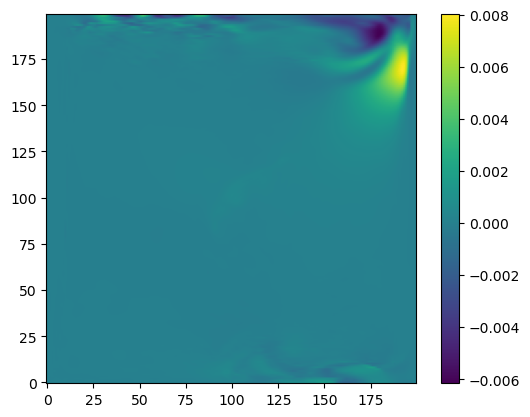

In [46]:
ux_diff = ux_gt-ux
plt.imshow(ux_diff.reshape(200,200), origin="lower")
plt.colorbar()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
timestep = 60.0
ux = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/U_{timestep}_predicted.npy")[:,0]
ux_gt = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/U_{timestep}.npy")[:,0]

t = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/T_{timestep}_predicted.npy")[:,0]
t_gt = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup/T_{timestep}.npy")

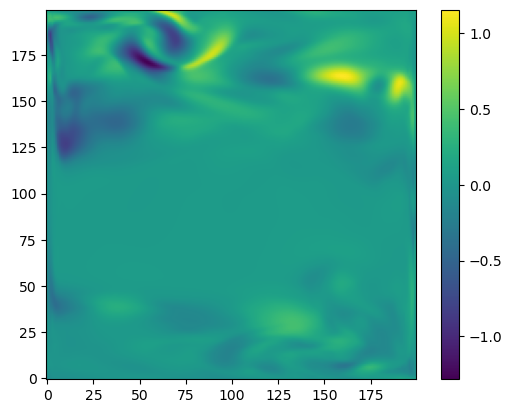

In [12]:
ux_diff = t_gt-t
plt.imshow(ux_diff.reshape(200,200), origin="lower")
plt.colorbar()

Text(0.5, 0, 'Switch count')

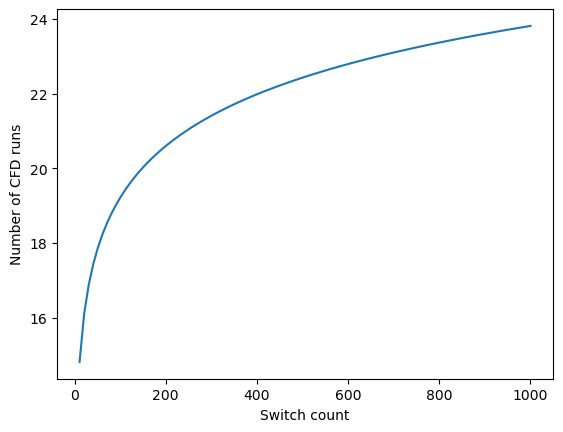

In [73]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 1000, 100)
y = 10+np.log(x**2)
plt.plot(x[1:], y[1:])
plt.ylabel("Number of CFD runs")
plt.xlabel("Switch count")

In [2]:
# Create a random dictionary:
import random
import numpy as np

random_dict = {i: np.random.rand(10) for i in range(5)}

# Plot Loss

In [1]:
from repitframework.plot_utils import save_loss
from repitframework.config import BaseConfig, TrainingConfig

training_config = TrainingConfig()
save_loss(training_config=training_config, merge_initial_losses=True)

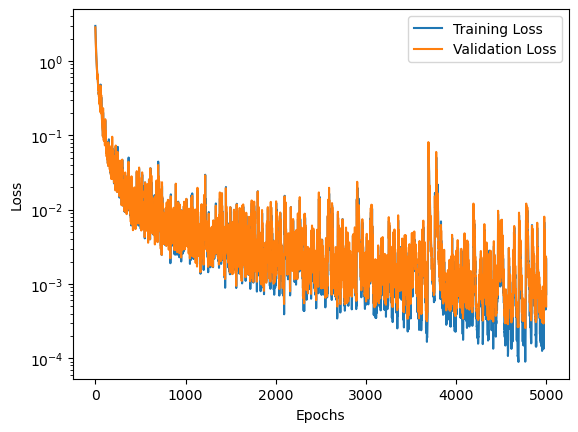

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import json

with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection_case1/training_metrics.json", "r") as f:
    metrics = json.load(f)

training_loss = metrics["Training Loss"]
validation_loss = metrics["Validation Loss"]
x = np.arange(0, len(training_loss), 1)
plt.plot(x, training_loss, label="Training Loss")
plt.plot(x, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.yscale("log")
plt.show()


In [6]:
validation_loss.index(min(validation_loss))

4767

In [18]:
output.shape

torch.Size([2, 40000, 3, 33])

In [19]:
inputs = torch.randn(2,40000,3,8)
weights = torch.randn(3,3,8)
output[:, :, :, :8] = torch.einsum("abi...,io...->abo...", inputs, weights)

In [27]:
y = torch.fft.irfftn(output, s=x.shape[-1], dim=(-1))

In [9]:
import torch

test = torch.randn(120000, 15)
test[:-40000].shape

torch.Size([80000, 15])

In [7]:
from einops import rearrange
import torch
x = torch.randn(200, 200)
x.transpose(1, 0)

tensor([[ 0.2455,  1.4991,  0.8270,  ...,  1.3372, -0.2282,  2.0425],
        [ 0.3558,  0.6023,  0.3432,  ..., -2.3872, -0.0530, -0.9554],
        [-0.3884, -2.0888,  0.0581,  ...,  0.0758,  0.8858,  0.0786],
        ...,
        [ 0.8487,  0.3497,  0.7339,  ..., -0.0922, -1.1220,  0.0967],
        [-0.4739, -0.1868,  0.3174,  ..., -0.2402, -0.1154, -0.7158],
        [-0.4915,  0.8682,  0.0882,  ..., -0.9841, -0.7454, -0.5256]])

In [8]:
x

tensor([[ 0.2455,  0.3558, -0.3884,  ...,  0.8487, -0.4739, -0.4915],
        [ 1.4991,  0.6023, -2.0888,  ...,  0.3497, -0.1868,  0.8682],
        [ 0.8270,  0.3432,  0.0581,  ...,  0.7339,  0.3174,  0.0882],
        ...,
        [ 1.3372, -2.3872,  0.0758,  ..., -0.0922, -0.2402, -0.9841],
        [-0.2282, -0.0530,  0.8858,  ..., -1.1220, -0.1154, -0.7454],
        [ 2.0425, -0.9554,  0.0786,  ...,  0.0967, -0.7158, -0.5256]])

In [82]:
input = torch.randn(80000, 64, 2)
weights = torch.randn(64,64,8)
torch.einsum("bi...,io...->bo...", input, weights)

RuntimeError: einsum(): dimension 2 covered by ellipsis in operand 1has size 8 which does not broadcast with previously seen ellipsis with size 2 for the respective dimension

In [10]:
import numpy as np
from repitframework.Dataset.fvmn import FVMNDataset
from repitframework.config import TrainingConfig

training_config = TrainingConfig()

In [46]:
temperature_1001 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/T_10.01.npy")
temperature_1001 = temperature_1001.reshape(200,200, order="F")
temperature_1001 = np.pad(temperature_1001, ((1, 1), (1, 1)), mode="edge")
temperature_1001[0, :] = 307.75
temperature_1001[-1, :] = 288.15
temperature_feature = FVMNDataset.add_feature(temperature_1001)


temperature_t = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1/T_10.64.npy")
temperature_t = temperature_t.reshape(200,200, order="F")
temperature_t = np.pad(temperature_t, ((1, 1), (1, 1)), mode="edge")
temperature_t[0, :] = 307.75
temperature_t[-1, :] = 288.15
temperature_tfeature = FVMNDataset.add_feature(temperature_t)

In [23]:
temp_mean = np.mean(temperature_feature, axis=0)
temp_std = np.std(temperature_feature, axis=0)
normed_temp = (temperature_feature - temp_mean) / temp_std

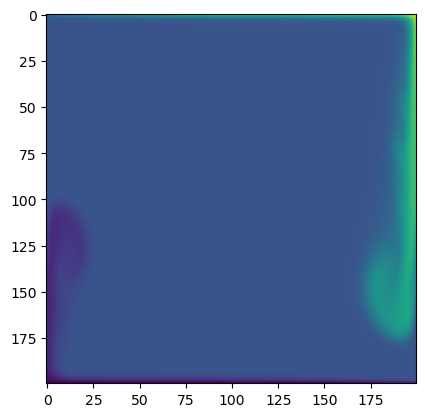

In [ ]:
plt.imshow(normed_temp[:,0].reshape(200,200, order="F"))

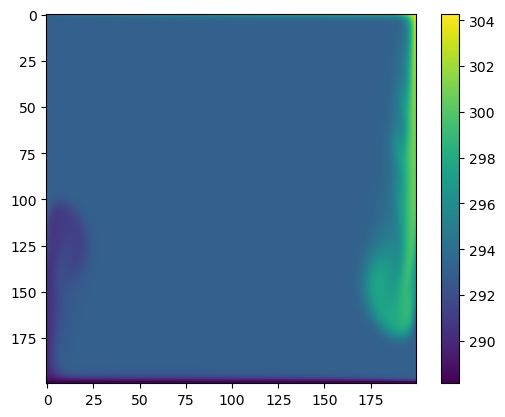

In [38]:
plt.imshow(temperature_feature[:,2].reshape(200,200, order="F"))
plt.colorbar()

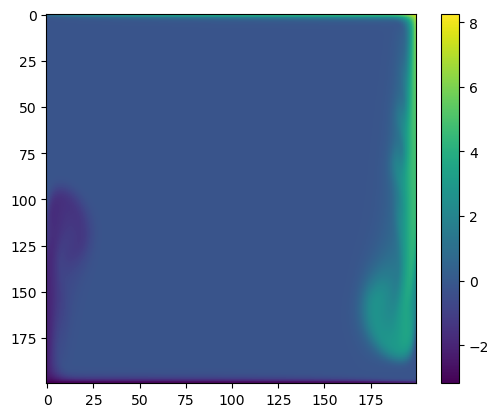

In [47]:
normed_tempt = (temperature_tfeature - temp_mean) / temp_std
plt.imshow(normed_tempt[:,0].reshape(200,200, order="F"))
plt.colorbar()

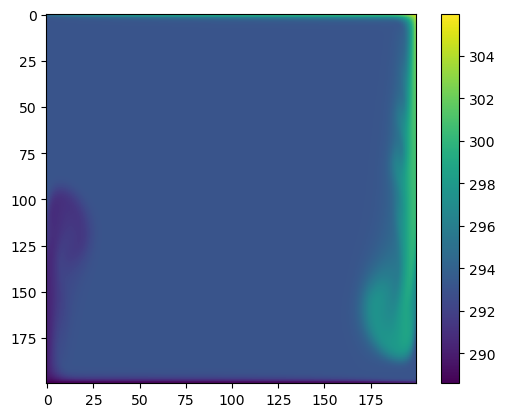

In [48]:
plt.imshow(temperature_tfeature[:,0].reshape(200,200, order="F"))
plt.colorbar()

In [51]:
temperature_tfeature[:, 0]

array([298.48603115, 294.30139492, 293.40815415, ..., 292.89360902,
       292.38511544, 290.67722022])

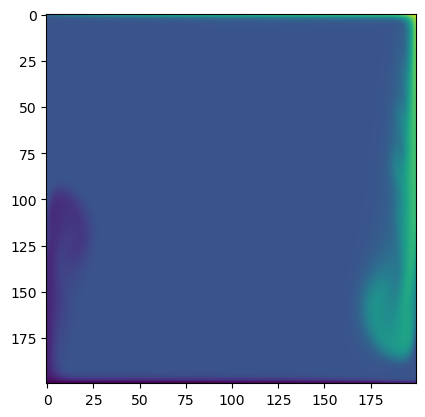

In [54]:
"""RePIT Framework: Hybrid CFD-ML Simulation Framework with Transfer Learning"""

from __future__ import annotations
from pathlib import Path
import timeit
import json
from typing import Tuple, List

import torch
import numpy as np
import torch.optim
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from repitframework.Dataset.fvmn import FVMNDataset
from repitframework.Models.FVMN.fvmn import FVMNetwork
from repitframework.config import TrainingConfig, OpenfoamConfig
from repitframework.OpenFOAM import OpenfoamUtils
from repitframework.OpenFOAM import numpyToFoam
from repitframework.Metrics.ResidualNaturalConvection import (
	residual_mass, 
	residual_momentum, 
	residual_heat
)
from repitframework.plot_utils import save_loss
from utils import load_from_state_dict


torch.set_default_dtype(torch.float64)
torch.manual_seed(1004)
torch.cuda.manual_seed_all(1004)
np.random.seed(1004)

def freeze_layers(model:torch.nn.Module, num_layers:int):
	'''
	Freeze the layers of the sub-network.
	'''
	for _, sub_network in model.networks.items():
		layers = list(sub_network.children())
		for layer in layers[:-num_layers]:
			for param in layer.parameters():
				param.requires_grad = False

def get_dataloader(training_config:TrainingConfig, 
				   dataset, 
				   batch_size=None):
	"""
	Returns DataLoaders that provide (x, y) batches for training and validation.
	
	If `dataset_phi` is provided, it ensures `x` and `y` batches are aligned correctly.
	"""
	batch_size = batch_size if batch_size else training_config.batch_size

	# Split indices for train/validation
	data_size = len(dataset)
	indices = list(range(data_size))
	# train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=1004)
	train_indices = indices[:int(2*data_size/3)]
	val_indices = indices[int(2*data_size/3):]

	train_dataset = Subset(dataset, train_indices)
	val_dataset = Subset(dataset, val_indices)

	# Create DataLoaders for X (dataset)
	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
	val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

	return train_loader, val_loader

class Trainer:
	def __init__(self, training_config:TrainingConfig, 
				 model:torch.nn.Module, 
				 optimizer:torch.optim.Optimizer, 
				 loss_fn:torch.nn.MSELoss, 
				 model_name:str=None):
		self.training_config = training_config
		self.device = training_config.device
		self.model = model
		self.model.to(self.device)

		# Change optimizer to LBFGS with line_search_fn="strong_wolfe"
		self.optimizer = torch.optim.LBFGS(
			self.model.parameters(),
			lr=training_config.learning_rate,
			max_iter=20,
			tolerance_grad=1e-5,
			tolerance_change=1e-9,
			line_search_fn="strong_wolfe"
		)

		self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
			self.optimizer, T_max=training_config.epochs, eta_min=1e-5
		)

		# Load the model if model_name is provided
		if model_name:
			self.load_model(model_name, load_optimizer=False)
			self.training_config.epochs = 0 # To skip initial training for 5000 epochs and use the best saved model from this training.
		self.loss_fn = loss_fn
		self.best_val_accuracy = float("inf")

		self.residual_threshold = training_config.residual_threshold
		self.relative_residual_mass = float()
		self.true_residual_mass = float()

		self.ux_matrix = torch.zeros((training_config.grid_y, training_config.grid_x))
		self.uy_matrix = torch.zeros((training_config.grid_y, training_config.grid_x))
		self.t_matrix = torch.zeros((training_config.grid_y, training_config.grid_x))
		self.t_matrix_prev = torch.zeros((training_config.grid_y, training_config.grid_x))
		self.ux_matrix_prev = torch.zeros((training_config.grid_y, training_config.grid_x))

		self.variables = self.training_config.get_variables()
		self.ux_index = self.variables.index("U_x")
		self.uy_index = self.variables.index("U_y")
		self.t_index = self.variables.index("T")

	def train(self, train_loader:DataLoader, 
			  val_loader:DataLoader, 
			  epochs, freeze:bool) -> bool:
		
		if freeze: freeze_layers(self.model, num_layers=4)
		for epoch in tqdm(range(epochs), desc="Epochs", leave=False):
			self.model.train()  # Set the model to training mode
			train_loss = 0.0
			# Update optimizer.step() to include a closure function for LBFGS
			for x_batch, y_batch in train_loader:
				x_batch = x_batch.to(self.device)
				y_batch = y_batch.to(self.device)

				# Define the closure function
				def closure():
					self.optimizer.zero_grad()
					predictions = self.model(x_batch)
					pred_T = predictions["T"]
					pred_ux = predictions["U_x"]
					pred_uy = predictions["U_y"]

					y_T = y_batch[:, self.t_index:self.t_index+1]
					y_ux = y_batch[:, self.ux_index:self.ux_index+1]
					y_uy = y_batch[:, self.uy_index:self.uy_index+1]

					loss_T = self.loss_fn(pred_T, y_T)
					loss_ux = self.loss_fn(pred_ux, y_ux)
					loss_uy = self.loss_fn(pred_uy, y_uy)
					loss = loss_T + loss_ux + loss_uy
					loss.backward()
					return loss

				# Call optimizer.step() with the closure
				self.optimizer.step(closure)

				train_loss += closure().item()*x_batch.size(0)
			
			train_loss /= len(train_loader.dataset)

			self.training_config.log_metrics(key="Epoch", value=epoch+1, metrics_type="training")
			self.training_config.log_metrics(key="Training Loss", value=train_loss, metrics_type="training")
			training_config.logger.debug(f"Epoch {epoch + 1}, Loss: {train_loss}")

			# Validation loss
			val_loss = self.validate(val_loader)
			if val_loss < self.best_val_accuracy:
				self.best_val_accuracy = val_loss
				self.save_model(f"best_model.pth")
			self.training_config.log_metrics(key="Validation Loss", value=val_loss, metrics_type="training")

		return True

	def validate(self, val_loader:DataLoader):
		self.model.eval()  # Set the model to evaluation mode
		val_loss = 0.0
		with torch.no_grad():
			for x_val, y_val in val_loader:
				x_val = x_val.to(self.device) 
				y_val = y_val.to(self.device)

				# Labels: 
				y_T = y_val[:,self.t_index:self.t_index+1]
				y_ux = y_val[:, self.ux_index:self.ux_index+1]
				y_uy = y_val[:, self.uy_index:self.uy_index+1]

				# Forward pass: Hard coded
				predictions = self.model(x_val)
				pred_T = predictions["T"]
				pred_ux = predictions["U_x"]
				pred_uy = predictions["U_y"]

				loss_T = self.loss_fn(pred_T, y_T)
				loss_ux = self.loss_fn(pred_ux, y_ux)
				loss_uy = self.loss_fn(pred_uy, y_uy)
				loss = loss_T + loss_ux + loss_uy
				val_loss += loss.item() * x_val.size(0)
		
		val_loss /= len(val_loader.dataset)
		training_config.logger.debug(f"Validation Loss: {val_loss:.4f}")
		return val_loss
	
	def train_with_PIL(self, train_loader:DataLoader, 
			  val_loader:DataLoader, 
			  epochs, freeze:bool,
			  switch_count:int=1) -> bool:
		
		if freeze: freeze_layers(self.model, num_layers=4)
		for epoch in tqdm(range(epochs), desc="Epochs", leave=False):
			self.model.train()  # Set the model to training mode
			train_loss = 0.0
			# Update optimizer.step() to include a closure function for LBFGS
			for x_batch, y_batch in train_loader:
				x_batch = x_batch.to(self.device)
				y_batch = y_batch.to(self.device)

				# Define the closure function
				def closure():
					self.optimizer.zero_grad()
					predictions = self.model(x_batch)
					pred_T = predictions["T"]
					pred_ux = predictions["U_x"]
					pred_uy = predictions["U_y"]

					y_T = y_batch[:, self.t_index:self.t_index+1]
					y_ux = y_batch[:, self.ux_index:self.ux_index+1]
					y_uy = y_batch[:, self.uy_index:self.uy_index+1]

					loss_T = self.loss_fn(pred_T, y_T)
					loss_ux = self.loss_fn(pred_ux, y_ux)
					loss_uy = self.loss_fn(pred_uy, y_uy)
					loss = loss_T + loss_ux + loss_uy

					#TODO: hard coded
					# Calculate the residuals
					loss_residual = residual_mass(ux_matrix=pred_ux.reshape(200,200), uy_matrix=pred_uy.reshape(200,200))
					loss += loss_residual
					loss.backward()
					return loss

				# Call optimizer.step() with the closure
				self.optimizer.step(closure)

				train_loss += closure().item()*x_batch.size(0)
			
			train_loss /= len(train_loader.dataset)

			self.training_config.log_metrics(key="Epoch", value=epoch+1, metrics_type="training")
			self.training_config.log_metrics(key="Training Loss", value=train_loss, metrics_type="training")
			training_config.logger.debug(f"Epoch {epoch + 1}, Loss: {train_loss:.4f}")

			# Validation loss
			val_loss = self.validate(val_loader)
			if val_loss < self.best_val_accuracy:
				self.best_val_accuracy = val_loss
				self.save_model(f"best_model.pth")
			self.training_config.log_metrics(key="Validation Loss", value=val_loss, metrics_type="training")

		return True

	def _normalize(self, data:torch.Tensor, mean:np.ndarray, std:np.ndarray):
		data = data.numpy()
		data = (data-mean) / std
		return torch.from_numpy(data)

	def _denormalize(self, data:torch.Tensor, mean:np.ndarray, std:np.ndarray):
		data = data.numpy()
		data = (data * std) + mean
		return torch.from_numpy(data)
	
	
	def predict(self, prediction_start_time:int|float=None, 
				write_interval:int|float=None, 
				data_path:Path=None):
		"""
		Parameters
		----------
		prediction_start_time: int|float:
			From which time step to start the prediction.
			Default is the prediction_start_time from the training config.
		write_interval: int|float:
			The interval at which the data is written.
			Default is the write_interval from the training config.
		data_path: Path:
			The path to the data directory.
		"""


		start_time = prediction_start_time if prediction_start_time else self.training_config.prediction_start_time
		time_step = write_interval if write_interval else self.training_config.write_interval
		data_path = Path(data_path) if data_path else self.training_config.assets_path 

		self.model.eval()
		prediction_input = None
		running_time = start_time # Because we saving the prediction data at prepare_input_for_prediction function. But, output is after calling this function.
		with torch.no_grad():
			# Load the mean and std from the training data: 
			metrics_path = self.training_config.model_dir / "denorm_metrics.json"
			with open(metrics_path, "r") as f:
				metrics = json.load(f)
			label_mean = np.array(metrics["label_MEAN"])
			label_std = np.array(metrics["label_STD"])
			input_mean = np.array(metrics["input_MEAN"])
			input_std = np.array(metrics["input_STD"])
			self.true_residual_mass = metrics["true_residual_mass"]

			while (self.relative_residual_mass <= self.residual_threshold) and (running_time <= self.training_config.prediction_end_time):
				prediction_input = self.prepare_input_for_prediction(running_time, data_path, prediction_input)
				normalized_input  = self._normalize(prediction_input, input_mean, input_std)
				predicted_output:torch.Tensor = self.model(normalized_input.to(self.device))
				predicted_output_concat = torch.cat([output.cpu() for output in predicted_output.values()], dim=1)
				denormed_output = self._denormalize(predicted_output_concat, label_mean, label_std)
				prediction_input = prediction_input[:, ::5] + denormed_output
				running_time = round(running_time+time_step, self.training_config.round_to)
				
			# Because prepare_input_for_prediction function calculates the residual values.
			# Hence, even if the residue value exceeds the threshold, the running time will be updated.
			# So, we need to step down the running time by the write interval outside the loop.
		return round(running_time-time_step, self.training_config.round_to)

	def save_model(self, model_name:str) -> Path:
		'''
		Parameters
		----------
		model_name: str: 
			The name of the model to be saved.
			Example: "model.pth"

		Returns
		-------
		model_save_path: Path: 
			The path where the model is saved.
			It will be saved in the repiframework/ModelDump/{case_name} directory.
		'''
		path = Path.joinpath(self.training_config.model_dir, model_name)
		torch.save({
			"model_state_dict": self.model.state_dict(),
			"optimizer_state_dict": self.optimizer.state_dict(),
			}, 
			path
		)
		self.training_config.logger.debug(f"Model saved as {model_name} at {self.training_config.model_dir}")
		return path

	def load_model(self, 
			model_name:str, 
			load_optimizer:bool=False,
			learning_rate:float=1e-4
			) -> torch.nn.Module:
		"""
		This is for transfer learning. We load the model from the saved model.
		Epochs= 20
		"""
		path = Path.joinpath(self.training_config.model_dir, model_name)
		checkpoint = torch.load(path, weights_only=True)
		self.model.load_state_dict(checkpoint["model_state_dict"])
		if load_optimizer and "optimizer_state_dict" in checkpoint:
			self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
			for param_group in self.optimizer.param_groups:
				param_group["lr"] = learning_rate
		self.training_config.logger.debug(f"Model loaded from {path}")
		return self.model.to(self.device)
	
	def get_ground_truth_data(
			self, 
			time_step:int|float, 
			data_path:Path=None
		) -> List[np.ndarray]:
		'''
		Because in FVMN, we are only predicting the interior points, we need to add the boundary data to the model output.
		Also, we need to calculate the residue. Hence, we need the true data for the time step.

		Args
		---- 
		data_path: Path: 
			If we predict for time step 5.03 then we need the original data for the 
			time step 5.03 to get the boundary data.This is the path to that data.
		time_step: float: 
			The time step for which we are predicting. e.g., 5.03
		first_prediction: bool: # TODO: This is not used. Remove it.
			If this is the first prediction, we return the whole data. 
			Else, we set the all the other except boundary to zero.

		Returns
		-------
		Each numpy array is the data for each variable separated dimension wise:
		e.g., [U_x, U_y, T] for each variable.
		
		ground_truth_data: List[np.ndarray]:
			Along with boundary values, we send the true values also.

		Functionality
		-------------
		1. Get the boundary data for the time step from ground truth data.
		2. Parse the numpy data for the variables.
		3. Separate the dimensions of the data if present. 
		5. Because to calculate the residue, we need true values also. 
		   Hence, this method returns true values also. 
		'''
		data_path = data_path if data_path else self.training_config.assets_path
		variables = self.training_config.extend_variables()
		full_data_path = [data_path / f"{var}_{time_step}.npy" for var in variables]
		numpy_data = [FVMNDataset.parse_numpy(self.training_config, data_path) for data_path in full_data_path]
		temp = list()
		for data in numpy_data:
			if len(data.shape) > 2:
				for i in range(self.training_config.data_dim):
					temp.append(data[:,:, i])
			else:
				temp.append(data)
		return temp
	
	def apply_boundary_conditions(self, pred_data:torch.Tensor, 
									time_step:int|float=None,
									data_path:Path=None,
									bc_type:str=None) -> torch.Tensor:
		'''
		Apply the boundary conditions to the data.

		Args
		----
		data: torch.Tensor:
			The data for which the boundary conditions are to be applied.
		type: str:
			Whether to add boundary values from ground truth or soft-constrained boundary values.\n
			None -> hard-constrained boundary values.\n \
			ground_truth -> ground truth boundary values.
		'''
		pred_data = pred_data.numpy()
		assert time_step and data_path, "Time step and Data path are required!"
			
		if bc_type == "ground_truth":
			ground_truth = self.get_ground_truth_data(time_step, data_path)

			# Modeling predicted data: adding zero padding to the predicted data.
			predicted_data_grid_x = self.training_config.grid_x - 2
			predicted_data_grid_y = self.training_config.grid_y - 2
			assert pred_data.shape[0] == predicted_data_grid_x * predicted_data_grid_y,\
				  f"Shape of the data is {pred_data.shape} but should be {(predicted_data_grid_x * predicted_data_grid_y, pred_data.shape[-1])}"
			pred_data = [pred_data[:, i].reshape(self.training_config.grid_y-2, self.training_config.grid_x-2,order="F") for i in range(pred_data.shape[-1])]

			# Copying just the boundary values from the ground truth data:
			for i in range(len(ground_truth)): ground_truth[i][1:-1, 1:-1] = 0 # Setting the internal nodes to zero.
			pad_pred_data = [np.pad(pred_data[i], 1, mode="constant",constant_values=0) for i in range(len(pred_data))]

			# Adding the zero padded predicted data to the zeroed internal nodes in the ground truth data.
			pred_data = [np.add(t,d) for t,d in zip(ground_truth, pad_pred_data)]

			# Saving the predicted data: True prediction are the ones after applying the boundary conditions.
			self.ux_matrix = pred_data[self.ux_index]
			self.uy_matrix = pred_data[self.uy_index]
			self.t_matrix = pred_data[self.t_index]
			
			return pred_data

		assert pred_data.shape[0] == self.training_config.grid_y * self.training_config.grid_x, \
			f"Shape of the data is {pred_data.shape} but should be {(self.training_config.grid_y * self.training_config.grid_x, pred_data.shape[-1])}"
		
		pred_data = [pred_data[:, i].reshape(self.training_config.grid_y, self.training_config.grid_x, order="F") for i in range(pred_data.shape[-1])]

		# Saving the predicted data: True prediction are the ones before applying the boundary conditions.
		self.ux_matrix = pred_data[self.ux_index]
		self.uy_matrix = pred_data[self.uy_index]
		self.t_matrix = pred_data[self.t_index]

		# Applying the boundary conditions
		pred_pad_data = self.training_config.hard_contraint_bc(pred_data)
		
		return pred_pad_data

	def calculate_residuals(self, time_step:int|float)->float:
		'''
		Calculate the residuals for the predicted data.
		'''
		# Calculate the residuals
		predicted_residual_mass = residual_mass(ux_matrix=self.ux_matrix, uy_matrix=self.uy_matrix)
		predicted_residual_momentum = residual_momentum(ux_matrix=self.ux_matrix, ux_matrix_prev=self.ux_matrix_prev,
															uy_matrix=self.uy_matrix, t_matrix=self.t_matrix)
		predicted_residual_heat = residual_heat(ux_matrix=self.ux_matrix, uy_matrix=self.uy_matrix,
													t_matrix=self.t_matrix, t_matrix_prev=self.t_matrix_prev)
		
		# Calculate the relative residual mass: 
		relative_residual_mass = predicted_residual_mass / self.true_residual_mass
		self.training_config.logger.debug(f"Relative Residual Mass: {relative_residual_mass}")

		self.training_config.log_metrics(key="Running Time", value=time_step)
		self.training_config.log_metrics(key="Predicted Residual Mass", value=predicted_residual_mass)
		self.training_config.log_metrics(key="True Residual Mass", value=self.true_residual_mass)
		self.training_config.log_metrics(key="Predicted Residual Momentum", value=predicted_residual_momentum)
		self.training_config.log_metrics(key="Predicted Residual Heat", value=predicted_residual_heat)
		self.training_config.log_metrics(key="Relative Residual Mass", value=relative_residual_mass)

		# Update the previous values
		self.ux_matrix_prev = self.ux_matrix
		self.t_matrix_prev = self.t_matrix

		return relative_residual_mass


	def prepare_input_for_prediction(self, time_step:int|float, 
									 data_path:Path, 
									 data:torch.Tensor=None) -> torch.Tensor:
		'''
		Adds ground truth boundary data to the predicted data and returns the feature selected input for the model.

		Args
		----
		time_step: int|float:
			If we are predicting for t then time_step = t-dt.
		data: torch.Tensor: 
			The output from the model after denormalizing and adding with the input [batch_size, num_features]
		data_path: Path: 
			if we predict for time step 5.03 then we need the original data for the time step 5.03 to get the boundary data.
		first_prediction: bool: 
			If this is the first prediction, we return the whole data. Else, we set the all the other except boundary to zero.

		Functionality
		-------------
		1. Get the boundary data for the time step from ground truth data.
		2. If this is not the first prediction, do the zero padding on the boundary of predicted data [198,198] -> [200,200].
		3. If not first prediction, internal nodes in the true data are set to zero.
		4. Because, we are using the same training_config.get_variables() to get the variables.
		   We leverage this to get the index of U_x, U_y, T.
		5. If it is not the first prediction, we are setting U_x and T values in that iteration as previous values 
		   and as the process progresses, we update the previous values with the predicted values.
		6. We save the predicted values here. In the prediction loop, we get the output for time(running_time) + dt.
		   So, it makes sense that we can update the running time, and while preparing input for the next prediction, 
		   we can add boundary values to the prev. predicted values and that would represent the predicted values for 
		   currently running_time in prediction loop.

		Reasoning
		---------
		But why did we assign the present/previous ux_matrix, uy_matrix, t_matrix in this function? 
		Because, we would have input and output data both in the predict method. Wouldn't it make sense to assign the values there?

		Sadly NO.
		Because, the input for the network is feature extracted. Example shape: [40000,15]
		And the output from the network is boundary excluded data. Example shape: [39204,3]
		Hence, we must do the post-processing before calculating the residue. So, for me, 
		it made a lot of sense to assign the values here. If you have a better idea, please let me know.
		'''
		if data is None:
			# If it is the first prediction, we need to get the ground truth data.
			ground_truth = self.get_ground_truth_data(time_step, data_path)
			self.ux_matrix_prev = ground_truth[self.ux_index]
			self.t_matrix_prev = ground_truth[self.t_index]
			# self.true_residual_mass = residual_mass(ground_truth[self.ux_index], ground_truth[self.uy_index])

			if self.training_config.bc_type != "ground_truth":
				ground_truth = self.training_config.hard_contraint_bc(ground_truth)

			temp_ = [FVMNDataset.add_feature(data) for data in ground_truth]
			input_data = np.concatenate(temp_, axis=-1)
			return torch.from_numpy(input_data)
		
		temp = self.apply_boundary_conditions(data, time_step, data_path, bc_type=self.training_config.bc_type)

		##################### Saving the predicted values #####################
		u_vector = np.concatenate([self.ux_matrix.reshape(-1,1, order="F"),
									self.uy_matrix.reshape(-1,1, order="F")], axis=-1)
		t_scalar = self.t_matrix.reshape(-1, order="F")
		np.save(data_path / f"U_{time_step}_predicted.npy", u_vector)
		np.save(data_path / f"T_{time_step}_predicted.npy", t_scalar)
		self.training_config.logger.debug(f"Saved variables at {data_path}")
		##################### Saved the predicted values #####################

		self.relative_residual_mass = self.calculate_residuals(time_step)
		
		temp_ = [FVMNDataset.add_feature(data) for data in temp]
		data = np.concatenate(temp_, axis=1)

		return torch.from_numpy(data)

def dynamic_parameters(switch_count:int)-> Tuple[int, int]:
	'''
	Returns the number of epochs and cfd runs based on the switch count.
	Args
	----
	switch_count: int:
		The number of times ML-CFD switch has happened.
	Returns
	-------
	epochs: int:
		The number of epochs to train the model.
	cfd_runs: int:
		The number of cfd runs to perform.
	'''
	if switch_count % 10 == 0:
		increment_factor_epochs = np.log(switch_count).item()
		increment_factor_cfd = np.log(switch_count**2).item()
		return int(2 + increment_factor_epochs), int(10 + increment_factor_cfd)
	return 2, 10

def hybrid_training( 
	openfoam_config:OpenfoamConfig, 
	training_config:TrainingConfig,
	network_type:torch.nn.Module=FVMNetwork,
	dataset_type:Dataset=FVMNDataset,
	) -> None:
	
	# Variables:
	# Training
	training_start_time = 10.61
	training_end_time = 10.64
	running_time = training_start_time
	optimizer = training_config.optimizer
	loss_fn = training_config.loss

	# Create model instance
	model = network_type(training_config)
	openfoam_utils = OpenfoamUtils(openfoam_config)

	##################### RePIT: START #####################
	framework_start_time = timeit.default_timer()

	trainer = Trainer(
		training_config=training_config, 
		model=model, 
		optimizer=optimizer, 
		loss_fn=loss_fn,
		model_name= None # Set this to None if you don't want to use pre-trained model.
	)

	# Storing times 
	cfd_times = 0.0
	ml_times = 0.0
	update_times = 0.0

	switch_count = 0
	ml_timesteps = 0
	cfd_timesteps = 0
	training_config.logger.info(f"Framework started at {timeit.default_timer()}")
	
	# Create dataset instance
	dataset = dataset_type(
		training_config=trainer.training_config,
		first_training=False, 
		start_time= training_start_time, 
		end_time=training_end_time, 
		time_step=trainer.training_config.write_interval
	)
		
	train_loader, val_loader = get_dataloader(
		training_config, 
		dataset, 
		batch_size=trainer.training_config.batch_size
	)

	update_end_time = timeit.default_timer()

	trainer.best_val_accuracy = float("inf") # Reset the best validation accuracy for transfer learning
	trainer.relative_residual_mass = 1.0 # Reset the relative residual mass for transfer learning



openfoam_config = OpenfoamConfig()
training_config = TrainingConfig()
# Run the main function
hybrid_training(openfoam_config, training_config)

# Start Prediction
# trainer = Trainer(training_config=training_config,
#                   model=FVMNetwork(training_config=training_config),
#                   optimizer=training_config.optimizer,
#                   loss_fn=training_config.loss,
#                   model_name="best_model.pth")
# trainer.predict(prediction_start_time=10.02, write_interval=0.01)

In [45]:
from repitframework.Dataset.fvmn import FVMNDataset
from repitframework.config import TrainingConfig


training_config = TrainingConfig()
dataset = FVMNDataset(
training_config=training_config,
data_path=training_config.assets_path,
first_training=False, 
start_time= 10.61, 
end_time=10.64, 
time_step=0.01
)

In [32]:
dataset = FVMNDataset(
training_config=training_config,
data_path="/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup",
first_training=False, 
start_time= 10.61, 
end_time=10.64, 
time_step=0.01
)

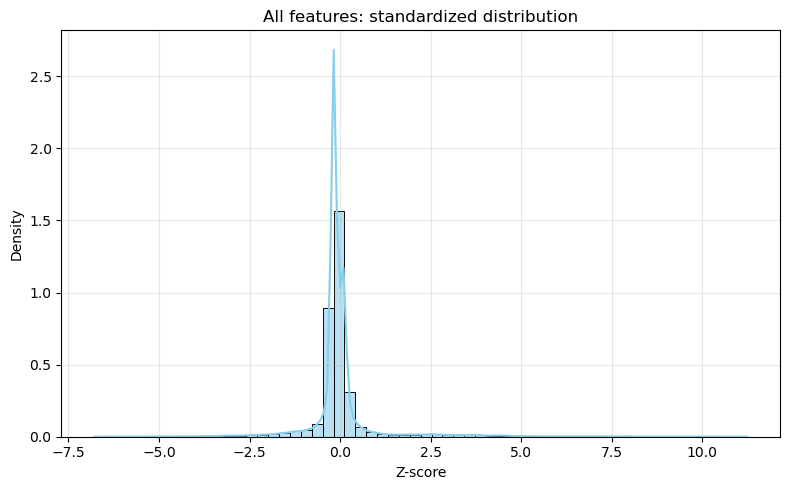

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Simulate your matrix (replace this with your actual data)
data, _ = dataset._prepare_inputs_and_labels()

# Step 2: Standardize the matrix column-wise

# Option A: Flatten for overall distribution
flattened = data.flatten()

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(flattened, bins=60, kde=True, stat="density", alpha=0.6, color='skyblue', edgecolor='black')
plt.title('All features: standardized distribution')
plt.xlabel('Z-score')
plt.ylabel('Density')
plt.grid('--',alpha=0.3)
plt.tight_layout()
plt.show()


# Per-Feature Distributions (Small Multiples)

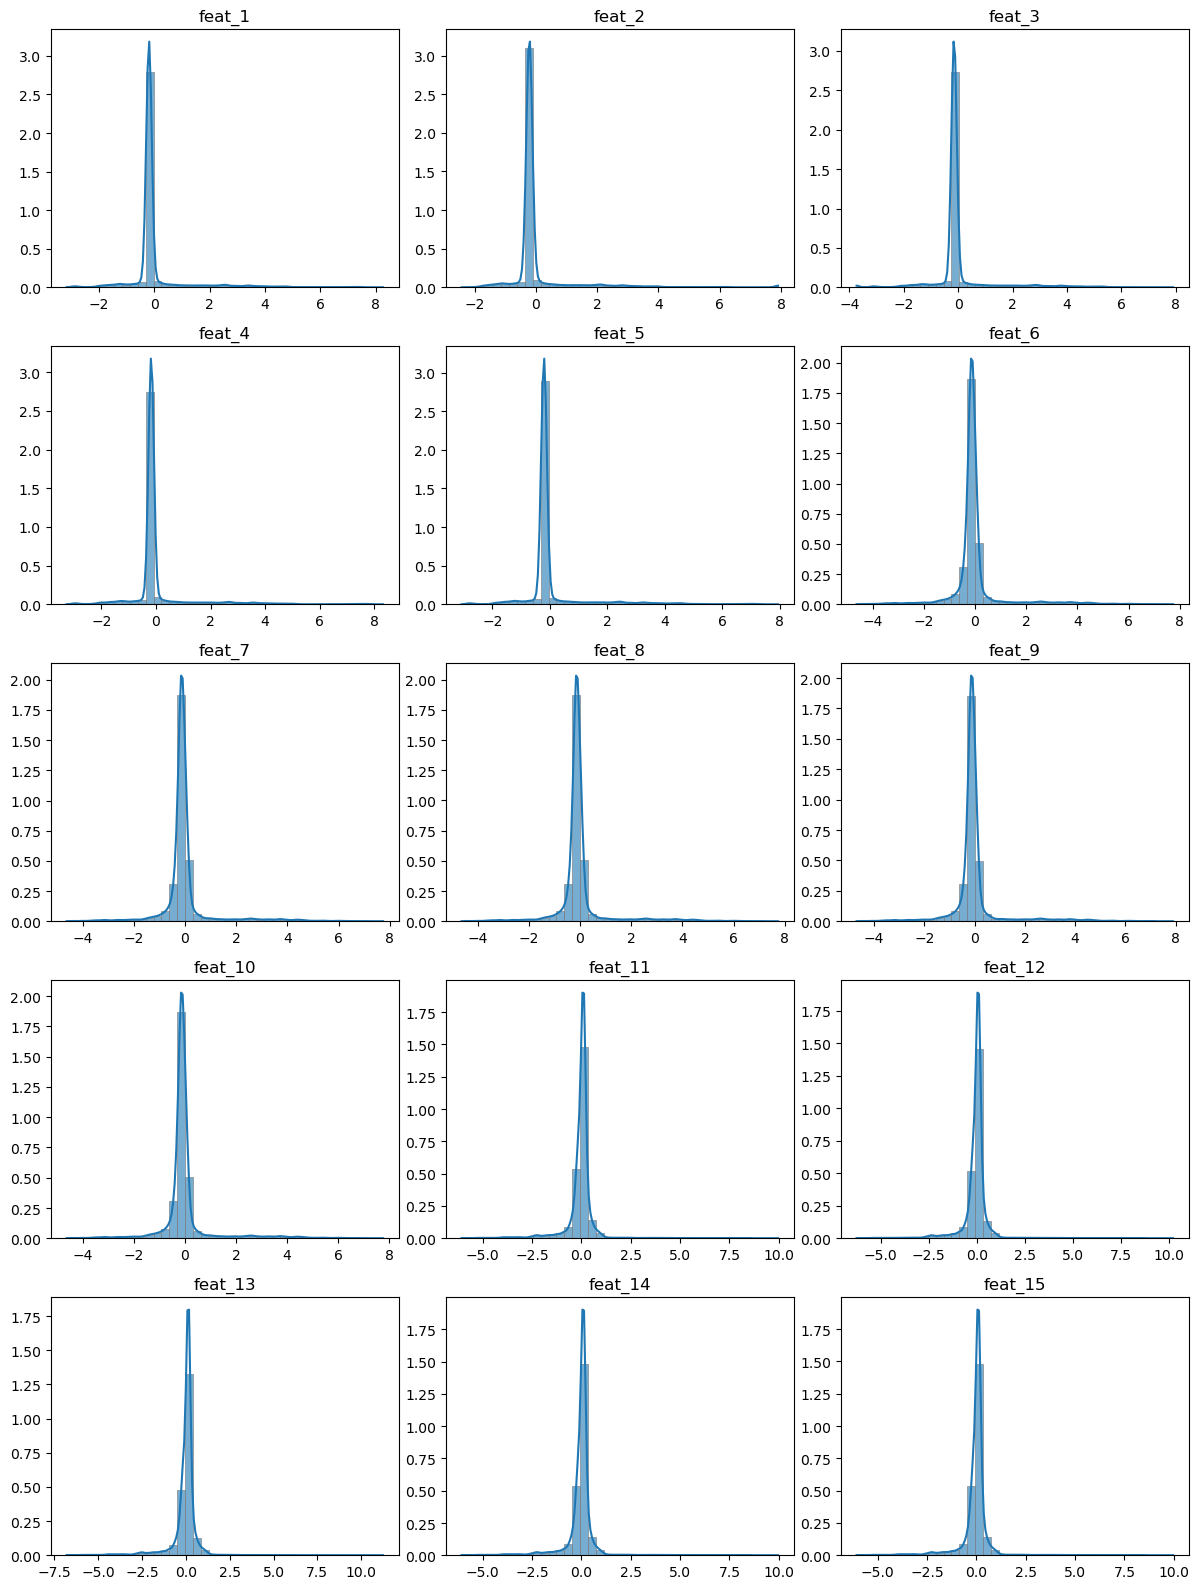

In [35]:
import pandas as pd

# build DataFrame for easy labeling
df = pd.DataFrame(data,
                  columns=[f"feat_{i}" for i in range(1,16)])

fig, axes = plt.subplots(5, 3, figsize=(12,16))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    sns.histplot(df[col], bins=40, kde=True, stat='density',
                 ax=ax, alpha=0.6, edgecolor='gray')
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

# hide any extra axes
for ax in axes[len(df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

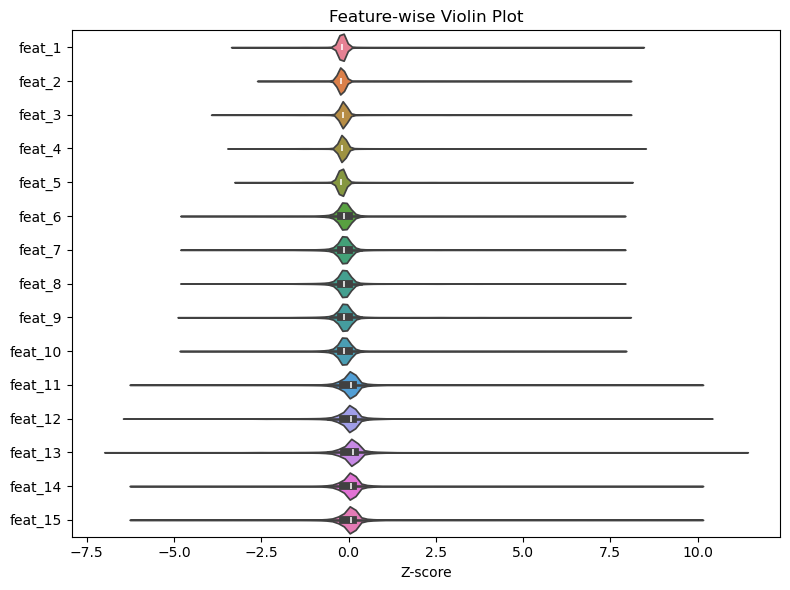

In [44]:
plt.figure(figsize=(8,6))
sns.violinplot(data=df, orient='h')
plt.title("Feature‑wise Violin Plot")
plt.xlabel("Z‑score")
plt.tight_layout()
plt.show()

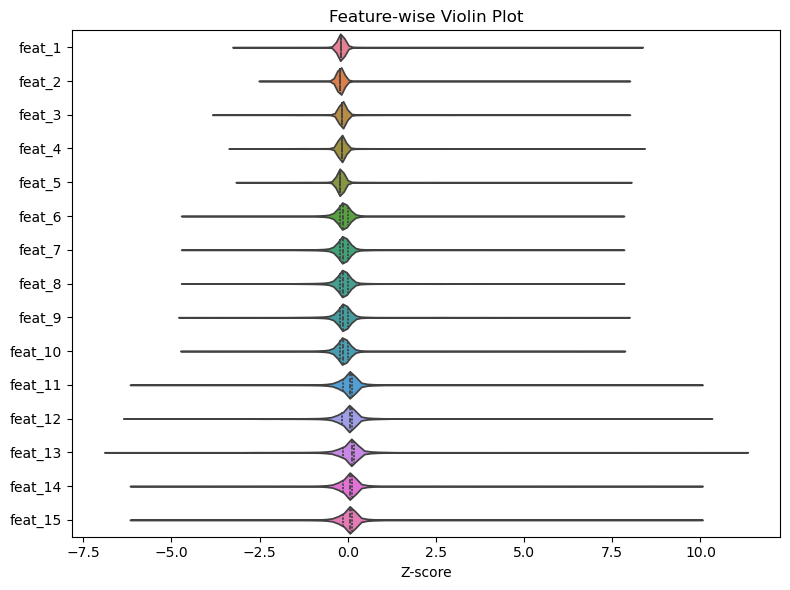

In [47]:
plt.figure(figsize=(8,6))
sns.violinplot(data=df, orient='h', inner='quartile', cut=1)
plt.title("Feature‑wise Violin Plot")
plt.xlabel("Z‑score")
plt.tight_layout()
plt.show()

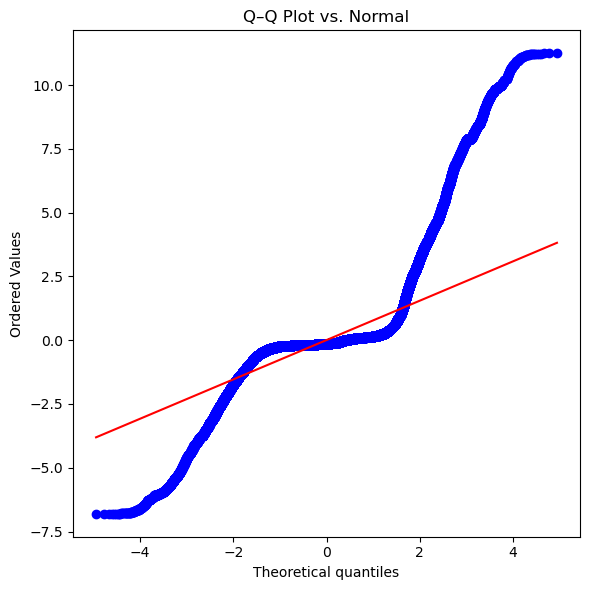

In [39]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(data.flatten(), plot=plt)
plt.title("Q–Q Plot vs. Normal")
plt.tight_layout()
plt.show()

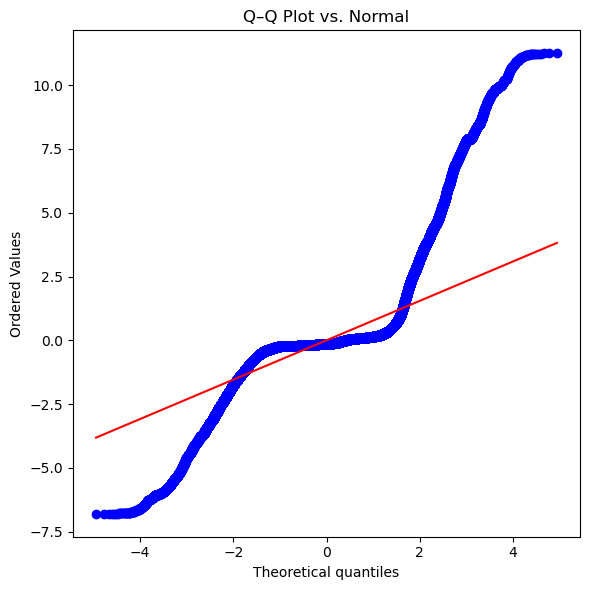

In [48]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(data.flatten(), plot=plt)
plt.title("Q–Q Plot vs. Normal")
plt.tight_layout()
plt.show()

In [5]:
498.0839325983643/252.19284277688712

1.975012165745778

# Simulating Output

In [4]:
from repitframework.plot_utils import visualize_output
import imageio
from repitframework.config import BaseConfig
import numpy as np
import json

base_config = BaseConfig()

time_list = [round(i,2) for i in np.arange(10.0, 110.0, 0.01)]
image_list = []


prediction_metrics_path = "/home/shilaj/repitframework/repitframework/ModelDump/natural_convection_case2/prediction_metrics.json"
with open(prediction_metrics_path, "r") as f:
	metrics = json.load(f)

predicted_time = metrics["Running Time"]
assets_path = "/home/shilaj/repitframework/repitframework/Assets/natural_convection_case2"
for time in time_list:
	if time in predicted_time:
		is_ground_truth = False
	else:
		is_ground_truth = True
	image_list.append(
		visualize_output(
			base_config=base_config,
			timestamp=time,
			np_data_dir=assets_path,
			data_vars=["T"],
			mode="rgb_array",
			is_ground_truth=is_ground_truth
		)
	)

imageio.mimsave(
		"temperature_simulation_case2_predicted.mp4", 
		image_list, 
		fps=500	)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (500, 500) to (512, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [5]:
import torch
from repitframework.Models.FVMN.fvmn import FVMNetwork
from repitframework.config import TrainingConfig
training_config = TrainingConfig()	

model = FVMNetwork(training_config=training_config)
checkpoint = torch.load("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection_case1/init_model.pth", weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>